# M01 - Phân tích lỗi  Phase 1 và Phase 2 (FIXED)

Notebook này đã được cập nhật theo mission M01: đọc cả `exphase_1_result` và `exphase_2_result`, có output sẵn, và dùng `Path.cwd()` để dễ mở trên máy khác.


## MỤC LỤC 
1. Tóm tắt Phase 1
2. Tóm tắt Phase 2
3. Bottleneck Phase 1
4. Bottleneck Phase 2
5. Top confusion Phase 1 và Phase 2
6. Nhóm class không ít ảnh nhưng nhầm nhiều
7. Handover
8. Data Visualization

In [5]:
from pathlib import Path
import pandas as pd

PROJECT = Path.cwd()
if not (PROJECT / "paper").exists():
    for candidate in [PROJECT.parent, PROJECT.parent.parent]:
        if (candidate / "paper").exists():
            PROJECT = candidate
            break

PHASE1 = PROJECT / "paper" / "result" / "exphase_1_result"
PHASE2 = PROJECT / "paper" / "result" / "exphase_2_result"
DATASET = PROJECT / "paper" / "cropped_dataset"

assert PHASE1.exists(), f"Không tìm thấy thư mục: {PHASE1}"
assert PHASE2.exists(), f"Không tìm thấy thư mục: {PHASE2}"
assert DATASET.exists(), f"Không tìm thấy thư mục: {DATASET}"

p1_validation = pd.read_csv(PHASE1 / "feature_svm_validation_results.csv")
p2_results = pd.read_csv(PHASE2 / "feature_svm_phase2_results.csv")
p2_report = pd.read_csv(PHASE2 / "val_classification_report_edge_histogram.csv", index_col=0)
p2_top_confusions = pd.read_csv(PHASE2 / "val_top_confusions_edge_histogram.csv")

print("PROJECT =", PROJECT)
print("PHASE1 tồn tại:", PHASE1.exists())
print("PHASE2 tồn tại:", PHASE2.exists())
print("DATASET tồn tại:", DATASET.exists())


PROJECT = e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26
PHASE1 tồn tại: True
PHASE2 tồn tại: True
DATASET tồn tại: True


In [6]:
SUPPORT_DIR = PROJECT / "workspace_Kiet" / "support"
assert SUPPORT_DIR.exists(), f"Kh?ng t?m th?y th? m?c support: {SUPPORT_DIR}"


def read_support_csv(name: str) -> pd.DataFrame:
    path = SUPPORT_DIR / name
    assert path.exists(), f"Kh?ng t?m th?y file support: {path}"
    return pd.read_csv(path)


phase1_bottleneck = read_support_csv("m01_phase12_bottleneck_phase1.csv")
phase2_bottleneck = read_support_csv("m01_phase12_bottleneck_phase2.csv")
top_confusions = read_support_csv("m01_phase12_top_confusions.csv")
confusion_groups = read_support_csv("m01_phase12_confusion_groups.csv")
handover_m2 = read_support_csv("m01_phase12_handover_m2.csv")
handover_m4 = read_support_csv("m01_phase12_handover_m4.csv")

print("Loaded M01 support outputs from:", SUPPORT_DIR)
print("phase1_bottleneck:", phase1_bottleneck.shape)
print("phase2_bottleneck:", phase2_bottleneck.shape)
print("top_confusions:", top_confusions.shape)
print("confusion_groups:", confusion_groups.shape)
print("handover_m2:", handover_m2.shape)
print("handover_m4:", handover_m4.shape)


Loaded M01 support outputs from: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\support
phase1_bottleneck: (10, 6)
phase2_bottleneck: (28, 6)
top_confusions: (24, 4)
confusion_groups: (4, 3)
handover_m2: (3, 3)
handover_m4: (28, 6)


## 1. Tóm tắt Phase 1


In [14]:
p1_validation.sort_values('val_macro_f1', ascending=False).head()


,case,features,feature_keys,n_features,train_seconds,val_accuracy,val_balanced_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1
0,Raw Pixels (Baseline),Raw Pixels (gray),raw_gray,4096,59.909299,0.942961,0.914509,0.972344,0.914509,0.934047,0.942376
1,HOG + Color Histogram - gray,HOG (gray) + Color Histogram (HSV),hog_gray+hist_hsv,2276,40.240549,0.955097,0.914015,0.963898,0.914015,0.932733,0.953546
2,HOG only - gray,HOG (gray),hog_gray,1764,29.588671,0.952670,0.911813,0.958103,0.911813,0.928592,0.950699
3,HOG only - yuv,HOG (YUV),hog_yuv,5292,135.790715,0.955097,0.911709,0.958130,0.911709,0.927394,0.952822
4,HOG + Color Histogram - yuv,HOG (YUV) + Color Histogram (HSV),hog_yuv+hist_hsv,5804,142.904578,0.955097,0.901814,0.959402,0.901814,0.920911,0.952630


## 2. Tóm tắt Phase 2


In [15]:
p2_results.sort_values('macro_f1', ascending=False)


,case,features,feature_keys,n_features,eval_split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,train_time_sec,inference_time_ms_per_image,predict_time_ms_per_image
0,Edge Histogram,Edge Histogram,edge_histogram,16,val,0.641990,0.607515,0.609466,0.587502,0.640616,0.883584,0.518051,0.403818
1,Gabor,Gabor,gabor,8,val,0.593447,0.568117,0.699511,0.587437,0.587503,0.765828,1.065085,0.362361
2,LBP,LBP,lbp,10,val,0.379854,0.318934,0.372002,0.307363,0.394689,1.072376,1.153238,0.428231
3,Hu Moments,Hu Moments,hu_moments,7,val,0.314320,0.261156,0.365685,0.251126,0.320610,1.189613,0.439222,0.408797


## 3. Bottleneck Phase 1

Phase 1 chưa có per-class report nên Recall/F1 là N/A.


In [16]:
if "phase1_bottleneck" not in globals():
    from pathlib import Path
    import pandas as pd
    PROJECT = Path.cwd()
    if not (PROJECT / "paper").exists():
        for candidate in [PROJECT.parent, PROJECT.parent.parent]:
            if (candidate / "paper").exists():
                PROJECT = candidate
                break
    phase1_bottleneck = pd.read_csv(PROJECT / "workspace_Kiet" / "support" / "m01_phase12_bottleneck_phase1.csv")

phase1_bottleneck


,Class ID,Train,Val Support,Recall Val (%),F1 Val (%),Chẩn đoán
0,R.301e,16,2,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
1,W.205c,17,2,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
2,I.409,20,3,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
3,S.505a_Xe máy,20,2,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
4,S.505a_Xe tải và công,21,3,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
5,W.239b_,21,3,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
6,P.124d,23,3,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
7,W.203c,23,3,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
8,W.205a,26,3,NaN,NaN,Phase 1 chưa có per-class report; xác định the...
9,W.225,28,4,NaN,NaN,Phase 1 chưa có per-class report; xác định the...


## 4. Bottleneck Phase 2

Phase 2 có per-class validation report, nên bảng này có Recall/F1 thật.


In [17]:
if "phase2_bottleneck" not in globals():
    from pathlib import Path
    import pandas as pd
    PROJECT = Path.cwd()
    if not (PROJECT / "paper").exists():
        for candidate in [PROJECT.parent, PROJECT.parent.parent]:
            if (candidate / "paper").exists():
                PROJECT = candidate
                break
    phase2_bottleneck = pd.read_csv(PROJECT / "workspace_Kiet" / "support" / "m01_phase12_bottleneck_phase2.csv")

phase2_bottleneck


,Class ID,Train,Val Support,Recall Val (%),F1 Val (%),Chẩn đoán
0,W.205a,26,3,0.00%,0.00%,"ít mẫu train, Recall Val < 60%, F1 Val < 60%"
1,W.205c,17,2,0.00%,0.00%,"ít mẫu train, Recall Val < 60%, F1 Val < 60%"
2,P.124d,23,3,33.33%,25.00%,"ít mẫu train, Recall Val < 60%, F1 Val < 60%"
3,W.246a,64,8,25.00%,25.00%,"Recall Val < 60%, F1 Val < 60%"
4,P.107,171,21,28.57%,33.33%,"Recall Val < 60%, F1 Val < 60%"
5,W.203c,23,3,33.33%,33.33%,"ít mẫu train, Recall Val < 60%, F1 Val < 60%"
6,I.409,20,3,33.33%,40.00%,"ít mẫu train, Recall Val < 60%, F1 Val < 60%"
7,P.127_80,168,21,38.10%,42.11%,"Recall Val < 60%, F1 Val < 60%"
8,W.207,204,26,38.46%,42.55%,"Recall Val < 60%, F1 Val < 60%"
9,P.104,36,4,50.00%,44.44%,"Recall Val < 60%, F1 Val < 60%"


## 5. Top confusion Phase 1 và Phase 2


In [18]:
if "top_confusions" not in globals():
    from pathlib import Path
    import pandas as pd
    PROJECT = Path.cwd()
    if not (PROJECT / "paper").exists():
        for candidate in [PROJECT.parent, PROJECT.parent.parent]:
            if (candidate / "paper").exists():
                PROJECT = candidate
                break
    top_confusions = pd.read_csv(PROJECT / "workspace_Kiet" / "support" / "m01_phase12_top_confusions.csv")

top_confusions


,Phase,Class thật,Class dự đoán,Số lần nhầm
0,Phase 1,P.130,P.131a,8
1,Phase 1,W.224,P.130,5
2,Phase 1,P.131a,P.130,4
3,Phase 1,P.127_80,P.127_60,3
4,Phase 1,W.207,W.224,2
5,Phase 1,P.103a,P.127_80,1
6,Phase 1,P.102,W.245a,1
7,Phase 1,P.103a,P.127_40,1
8,Phase 1,Camera,P.130,1
9,Phase 1,I.409,P.127_40,1


## 6. Nhóm class không ít ảnh nhưng nhầm nhiều


In [19]:
if "confusion_groups" not in globals():
    from pathlib import Path
    import pandas as pd
    PROJECT = Path.cwd()
    if not (PROJECT / "paper").exists():
        for candidate in [PROJECT.parent, PROJECT.parent.parent]:
            if (candidate / "paper").exists():
                PROJECT = candidate
                break
    confusion_groups = pd.read_csv(PROJECT / "workspace_Kiet" / "support" / "m01_phase12_confusion_groups.csv")

confusion_groups


,Nhóm lỗi,Class liên quan,Bằng chứng
0,Nhầm biển giống nhau,"P.130, P.131a",Phase 1 và Phase 2 đều có P.130/P.131a trong t...
1,Nhầm biển tốc độ,"P.127_40, P.127_50, P.127_60, P.127_80",Phase 2 nhầm P.127_60 -> P.127_50/80 và P.127_...
2,Nhầm với class lớn P.102/P.130,"P.102, P.130, R.302a, P.124c, P.131a",Phase 2 top confusion có nhiều class bị hút về...
3,Nhầm biển cảnh báo,"W.207, W.224, W.245a",Phase 1/2 đều ghi nhận W.207/W.224 hoặc W.224/...


## 7. Handover


In [20]:
if "handover_m2" not in globals() or "handover_m4" not in globals():
    from pathlib import Path
    import pandas as pd
    PROJECT = Path.cwd()
    if not (PROJECT / "paper").exists():
        for candidate in [PROJECT.parent, PROJECT.parent.parent]:
            if (candidate / "paper").exists():
                PROJECT = candidate
                break
    support_dir = PROJECT / "workspace_Kiet" / "support"
    handover_m2 = pd.read_csv(support_dir / "m01_phase12_handover_m2.csv")
    handover_m4 = pd.read_csv(support_dir / "m01_phase12_handover_m4.csv")

handover_m2, handover_m4


(                   Nhóm/Class  \
 0            Biển không vuông   
 1           P.127_40/50/60/80   
 2  P.130/P.131a và nhóm P.102   
 
                                                Lý do  \
 0  Phase 1 resize trực tiếp 64x64, Phase 2 vẫn có...   
 1                     Nhầm biển tốc độ trong Phase 2   
 2            Nhóm class hút nhầm nhiều trong Phase 2   
 
                                         Việc cần làm  
 0                   Kiểm chứng pad_square vs stretch  
 1        Kiểm tra resolution/resize để giữ rõ chữ số  
 2  Kiểm tra feature có đủ phân biệt chi tiết ký h...  ,
                     Class  Train Recall Val  F1 Val  \
 0                  W.205a     26      0.00%   0.00%   
 1                  W.205c     17      0.00%   0.00%   
 2                  P.124d     23     33.33%  25.00%   
 3                  W.246a     64     25.00%  25.00%   
 4                   P.107    171     28.57%  33.33%   
 5                  W.203c     23     33.33%  33.33%   
 6             

## 8 Data Visualization

Current working directory: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01
Workspace directory: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet
Support directory: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\support
Output directory: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01_outputs\figures
Loaded phase1_bottleneck: (10, 6) -> e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\support\m01_phase12_bottleneck_phase1.csv
Loaded phase2_bottleneck: (28, 6) -> e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\support\m01_phase12_bottleneck_phase2.csv
Loaded top_confusions: (24, 4) -> e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\support\m01_phase12_top_confusions.csv
Loaded confusion_groups: (4, 3) -> e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\s

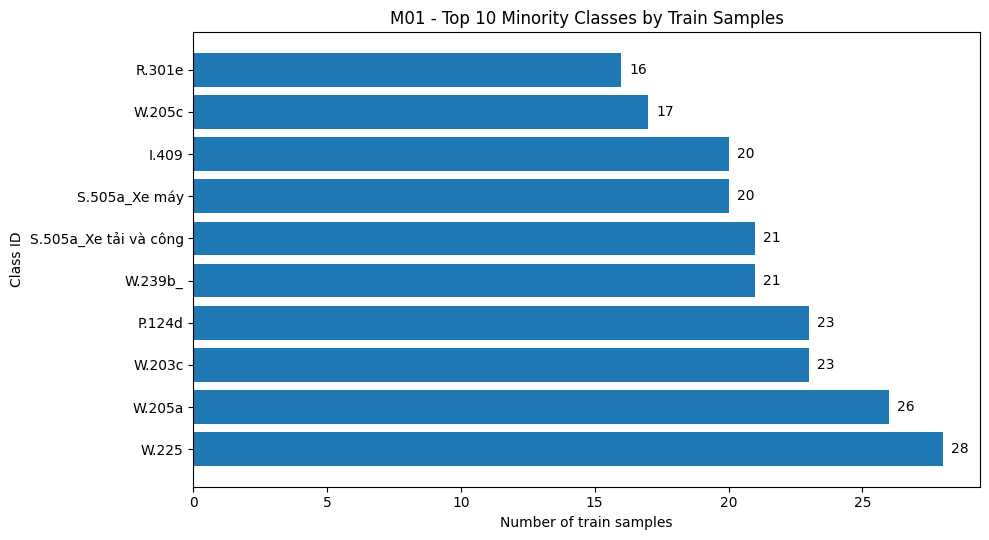

Saved: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01_outputs\figures\m01_fig1_top10_minority_classes.png


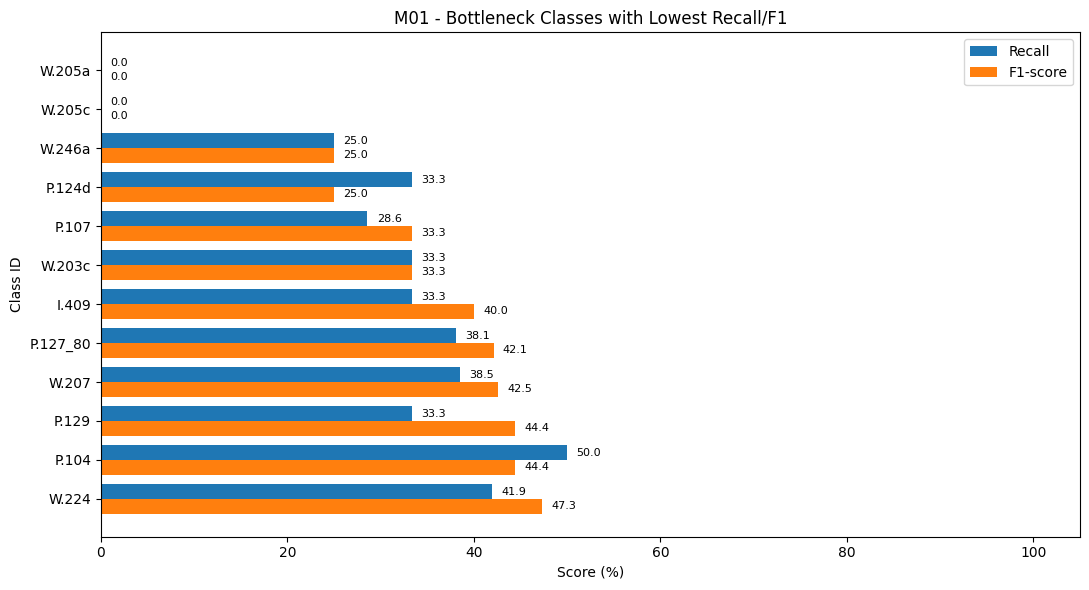

Saved: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01_outputs\figures\m01_fig2_bottleneck_lowest_recall_f1.png


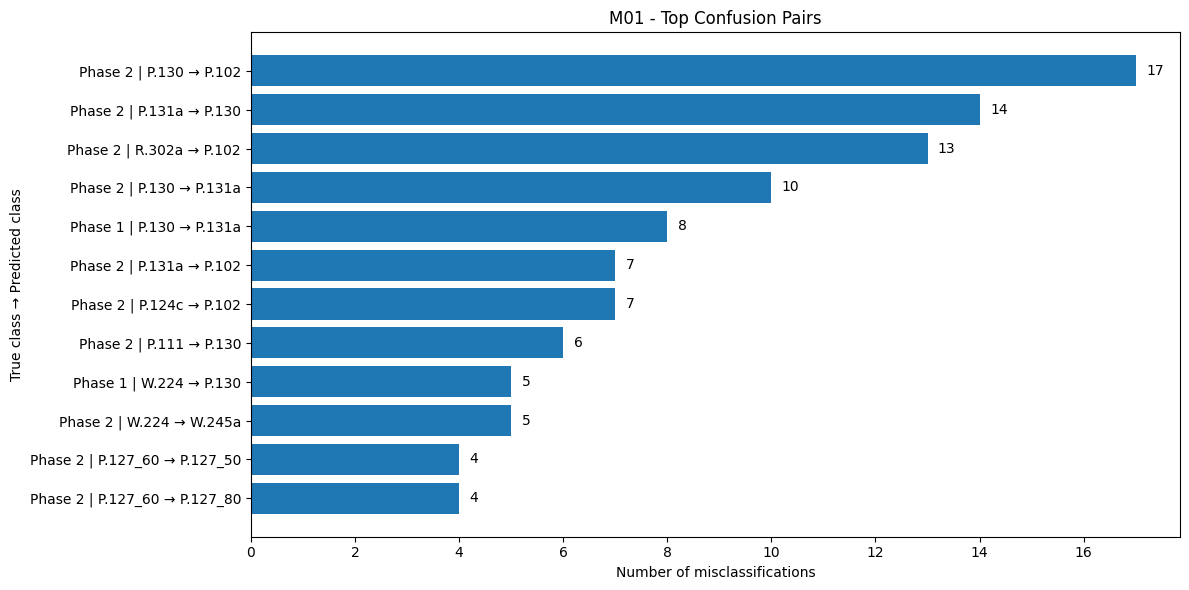

Saved: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01_outputs\figures\m01_fig3_top_confusion_pairs.png


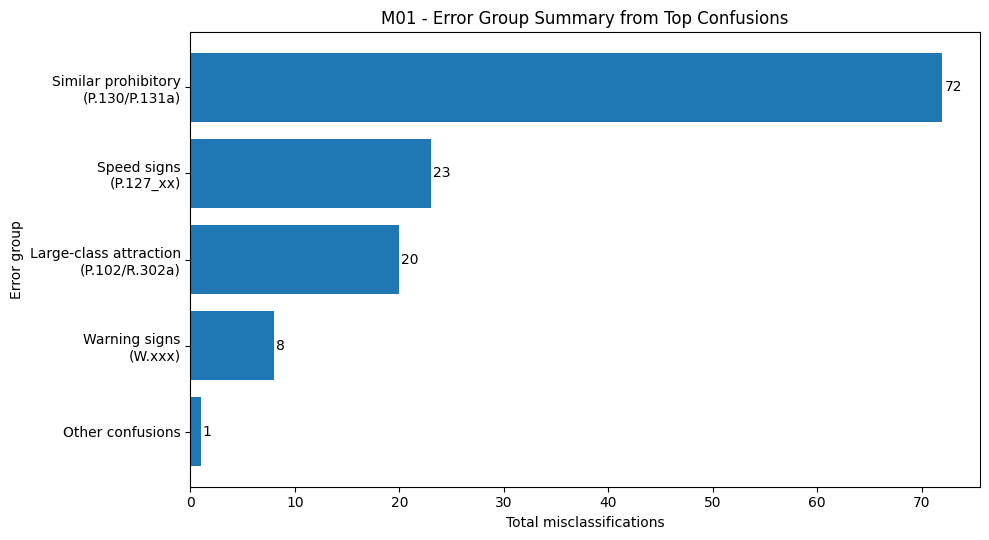

Saved: e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01_outputs\figures\m01_fig4_error_group_summary.png

Done. M01 visualization figures are saved in:
e:\tai lieu\machine learning\project_final\AIL303m_FUDN_SUM26\workspace_Kiet\m01_outputs\figures


In [21]:
# ============================================================
# M01 VISUALIZATION CELL
# Visualize Minority Classes, Bottleneck Classes, Top Confusions
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Setup paths
# ----------------------------
PROJECT_ROOT = Path.cwd()

PROJECT_ROOT = Path.cwd()

# Nếu notebook đang nằm trong workspace_Kiet/m01
if PROJECT_ROOT.name.lower() == "m01":
    WORKSPACE_DIR = PROJECT_ROOT.parent
else:
    WORKSPACE_DIR = PROJECT_ROOT

SUPPORT_DIR = WORKSPACE_DIR / "support"
OUTPUT_DIR = WORKSPACE_DIR / "m01_outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", PROJECT_ROOT)
print("Workspace directory:", WORKSPACE_DIR)
print("Support directory:", SUPPORT_DIR)
print("Output directory:", OUTPUT_DIR)

FILES = {
    "phase1_bottleneck": "m01_phase12_bottleneck_phase1.csv",
    "phase2_bottleneck": "m01_phase12_bottleneck_phase2.csv",
    "top_confusions": "m01_phase12_top_confusions.csv",
    "confusion_groups": "m01_phase12_confusion_groups.csv",
    "handover_m2": "m01_phase12_handover_m2.csv",
    "handover_m4": "m01_phase12_handover_m4.csv",
}

def read_csv_safe(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="utf-8")

def find_col(df, candidates):
    """
    Find a column name robustly.
    Example: 'Class ID', 'class_id', 'class id' đều tìm được.
    """
    norm_map = {
        str(c).lower().strip().replace("_", " ").replace("-", " "): c
        for c in df.columns
    }

    for cand in candidates:
        cand_norm = cand.lower().strip().replace("_", " ").replace("-", " ")
        if cand_norm in norm_map:
            return norm_map[cand_norm]

    for cand in candidates:
        cand_norm = cand.lower().strip().replace("_", " ").replace("-", " ")
        for norm_name, original_name in norm_map.items():
            if cand_norm in norm_name:
                return original_name

    return None

def to_percent(series):
    """
    Convert percent-like values to 0-100 scale.
    Accepts: 0.95, 95, '95%', '0.95'
    """
    s = series.astype(str).str.replace("%", "", regex=False).str.strip()
    s = pd.to_numeric(s, errors="coerce")

    # Nếu giá trị nằm trong [0, 1] thì xem như tỷ lệ và nhân 100
    if s.dropna().between(0, 1).all():
        s = s * 100

    return s

def save_show(fig, filename):
    path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

# ----------------------------
# 2. Load M01 support files
# ----------------------------
loaded = {}

for key, filename in FILES.items():
    path = SUPPORT_DIR / filename
    if path.exists():
        loaded[key] = read_csv_safe(path)
        print(f"Loaded {key}: {loaded[key].shape} -> {path}")
    else:
        print(f"Missing: {path}")

phase1 = loaded.get("phase1_bottleneck")
phase2 = loaded.get("phase2_bottleneck")
confusions = loaded.get("top_confusions")

# ----------------------------
# 3. Figure 1: Top minority classes by train samples
# ----------------------------
if phase1 is not None and not phase1.empty:
    class_col = find_col(phase1, ["class id", "class", "label", "Class ID"])
    train_col = find_col(phase1, ["train", "train support", "train count", "Train"])

    if class_col and train_col:
        df = phase1.copy()
        df[train_col] = pd.to_numeric(df[train_col], errors="coerce")
        df = df.dropna(subset=[train_col])
        df = df.sort_values(train_col, ascending=True).head(10)

        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.barh(df[class_col].astype(str), df[train_col])
        ax.set_title("M01 - Top 10 Minority Classes by Train Samples")
        ax.set_xlabel("Number of train samples")
        ax.set_ylabel("Class ID")
        ax.invert_yaxis()

        for i, v in enumerate(df[train_col]):
            ax.text(v + 0.3, i, str(int(v)), va="center")

        save_show(fig, "m01_fig1_top10_minority_classes.png")
    else:
        print("Cannot plot Figure 1: class/train column not found.")

# ----------------------------
# 4. Figure 2: Bottleneck classes with lowest Recall/F1
# ----------------------------
if phase2 is not None and not phase2.empty:
    class_col = find_col(phase2, ["class id", "class", "label", "Class ID"])
    recall_col = find_col(phase2, ["recall val", "val recall", "recall", "Recall Val"])
    f1_col = find_col(phase2, ["f1 val", "val f1", "f1-score", "f1 score", "f1", "F1 Val"])

    if class_col and recall_col and f1_col:
        df = phase2.copy()
        df["Recall (%)"] = to_percent(df[recall_col])
        df["F1 (%)"] = to_percent(df[f1_col])
        df = df.dropna(subset=["Recall (%)", "F1 (%)"])
        df = df.sort_values(["F1 (%)", "Recall (%)"], ascending=True).head(12)

        y = np.arange(len(df))
        height = 0.38

        fig, ax = plt.subplots(figsize=(11, 6))
        ax.barh(y - height/2, df["Recall (%)"], height, label="Recall")
        ax.barh(y + height/2, df["F1 (%)"], height, label="F1-score")

        ax.set_yticks(y)
        ax.set_yticklabels(df[class_col].astype(str))
        ax.set_title("M01 - Bottleneck Classes with Lowest Recall/F1")
        ax.set_xlabel("Score (%)")
        ax.set_ylabel("Class ID")
        ax.set_xlim(0, 105)
        ax.legend()
        ax.invert_yaxis()

        for i, (r, f) in enumerate(zip(df["Recall (%)"], df["F1 (%)"])):
            ax.text(r + 1, i - height/2, f"{r:.1f}", va="center", fontsize=8)
            ax.text(f + 1, i + height/2, f"{f:.1f}", va="center", fontsize=8)

        save_show(fig, "m01_fig2_bottleneck_lowest_recall_f1.png")
    else:
        print("Cannot plot Figure 2: class/recall/f1 column not found.")

# ----------------------------
# 5. Figure 3: Top confusion pairs
# ----------------------------
if confusions is not None and not confusions.empty:
    phase_col = find_col(confusions, ["phase", "Phase"])
    true_col = find_col(confusions, ["true class", "true", "actual", "y_true", "Class thật"])
    pred_col = find_col(confusions, ["predicted class", "pred", "prediction", "y_pred", "Class dự đoán"])
    count_col = find_col(confusions, ["count", "num", "n", "Số lần nhầm"])

    if true_col and pred_col and count_col:
        df = confusions.copy()
        df[count_col] = pd.to_numeric(df[count_col], errors="coerce")
        df = df.dropna(subset=[count_col])
        df["pair"] = df[true_col].astype(str) + " → " + df[pred_col].astype(str)

        if phase_col:
            df["pair"] = df[phase_col].astype(str) + " | " + df["pair"]

        df = df.sort_values(count_col, ascending=False).head(12)

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.barh(df["pair"], df[count_col])
        ax.set_title("M01 - Top Confusion Pairs")
        ax.set_xlabel("Number of misclassifications")
        ax.set_ylabel("True class → Predicted class")
        ax.invert_yaxis()

        for i, v in enumerate(df[count_col]):
            ax.text(v + 0.2, i, str(int(v)), va="center")

        save_show(fig, "m01_fig3_top_confusion_pairs.png")
    else:
        print("Cannot plot Figure 3: true/pred/count column not found.")

# ----------------------------
# 6. Figure 4: Error group summary from top confusions
# ----------------------------
if confusions is not None and not confusions.empty:
    true_col = find_col(confusions, ["true class", "true", "actual", "y_true", "Class thật"])
    pred_col = find_col(confusions, ["predicted class", "pred", "prediction", "y_pred", "Class dự đoán"])
    count_col = find_col(confusions, ["count", "num", "n", "Số lần nhầm"])

    if true_col and pred_col and count_col:
        df = confusions.copy()
        df[count_col] = pd.to_numeric(df[count_col], errors="coerce")
        df = df.dropna(subset=[count_col])

        def assign_error_group(row):
            true_label = str(row[true_col])
            pred_label = str(row[pred_col])
            labels = true_label + " " + pred_label

            if "P.127" in labels:
                return "Speed signs\n(P.127_xx)"
            elif ("P.130" in labels) or ("P.131a" in labels):
                return "Similar prohibitory\n(P.130/P.131a)"
            elif ("W.207" in labels) or ("W.224" in labels) or ("W.245a" in labels):
                return "Warning signs\n(W.xxx)"
            elif ("P.102" in labels) or ("R.302a" in labels):
                return "Large-class attraction\n(P.102/R.302a)"
            else:
                return "Other confusions"

        df["error_group"] = df.apply(assign_error_group, axis=1)
        group_df = (
            df.groupby("error_group", as_index=False)[count_col]
            .sum()
            .sort_values(count_col, ascending=True)
        )

        fig, ax = plt.subplots(figsize=(10, 5.5))
        ax.barh(group_df["error_group"], group_df[count_col])
        ax.set_title("M01 - Error Group Summary from Top Confusions")
        ax.set_xlabel("Total misclassifications")
        ax.set_ylabel("Error group")

        for i, v in enumerate(group_df[count_col]):
            ax.text(v + 0.2, i, str(int(v)), va="center")

        save_show(fig, "m01_fig4_error_group_summary.png")
    else:
        print("Cannot plot Figure 4: true/pred/count column not found.")

print("\nDone. M01 visualization figures are saved in:")
print(OUTPUT_DIR)